# First Jupyter Notebook: A Basic Exploration

With this introductory exercise, we will review the essentials of using a Jupyter Notebook and play around with a sample dataset.  The goal is to learn more about the environment and how we can work with data while documenting our work.

## Helpful Keyboard Shortcuts

**Esc**: Switch to Command Mode

**Enter**: Switch to Edit Mode

**Ctrl+Enter** (Windows): Run the selected cell

**Shift+Enter**: Run the selected cell and move to the cell below  

**Alt+Enter**: Run the selected cell and insert cell below

**a** / **b**: Create a cell above (a) or below (b) the current cell

**m** to switch a code cell to a markdown cell

**y** to switch a markdown cell to a code cell

There are many more. See https://digitalhumanities.hkust.edu.hk/tutorials/jupyter-notebook-tips-and-shortcuts/ for more. But these will do for now. 

In [3]:
# Get started with needed imports 
# Good idea to always put these at the top
import numpy as np # needed for routine stat analysis
import pandas as pd # gives us the power of working with dataframes
import matplotlib.pyplot as plt # for visualizationd
import seaborn as sb # for more visualization

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

After you run the cell above, notice the number in brackets to the left of the cell. This indicates the order position in the execution order within the current **kernel session**. 

In Jupyter Notebook, a **kernel** is a computational engine that executes the code you write in your notebook cells. It is a separate process from the Jupyter Notebook server itself, responsible for running code in a specific programming language (e.g., Python) and managing the state of your session.

A kernel session refers to the active connection between a Jupyter Notebook frontend (your web browser interface) and a running kernel process. When you open a Jupyter Notebook, a kernel is launched and a session is established. This session maintains the environment in which your code runs, including variables, data structures, and environment info (e.g. modules installed).

Each notebook has its own session. Stopping the Juypter notebook server will end the kernel session.

### Load and View Data

Let's load the dataset for titanic. We'll load the data into a new data structure, the **DataFrame**.  A DataFrame is a two-dimensional, size-mutable, and potentially heterogeneous tabular data structure with labeled axes (rows and columns).

In [5]:
# loading data into a dataframe
df = pd.read_csv('train.csv')

Let's see what we've got!

In [11]:
# View first five rows of the dataframe
# try typing pd.<tab> to see options
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Not that the above code automatically resulted in the notebook displaying the result of this function call.  We didn't need to use print(). 

When you work with data, you'll want to spend sometime making sure you understand the data. The standard Titanic dataset contains columns such as PassengerId (unique identifier), Survived (0=No, 1=Yes), Pclass (1st, 2nd, or 3rd class), Name, Sex, Age, SibSp (number of siblings/spouses), Parch (number of parents/children), Ticket (ticket number), Fare, Cabin, and Embarked (port of embarkation). 

In [13]:
# TODO: View last five rows of the dataframe
# Guess the method
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Exploring the data
Let's do some **EDA** (exploratory data analysis). EDA is used to explore, summarize, and analyze data sets. It involves using basic statistics and visualizations to better understand the data set. EDA is an important step of data science.

Let's first determine how many records we have.

In [15]:
# TODO: We can pass our dataframe to the Python built-in len() function to determine the number of records in the data set. 
len(df)

891

In [19]:
# We can use other methods specific to DataFrames to learn more about their characteristics. 
# TODO: Use the DataFrame describe() method to get some basic stats. 
len(df)
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


If we want to do both of the above actions in one cell, use the print() function so we can see both outputs.

In [21]:
# Seeing output of two function calls in one cell 
print("Number of records")
print(len(df))

print("\nBasic summary statistics")
print(df.describe())

Number of records
891

Basic summary statistics
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


What if you want to know what data types you are working with within the DataFrame?  

In [23]:
# Check the data types of variables
# TODO: use the DataFrame dtypes property
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

We often look for possible missing data. DataFrames have functions to make this go a bit quicker. We can pair this with basic Python library built-in functions like sum().

In [25]:
# Check for missing values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We can also get the above information by using the DataFrame info() method.

In [27]:
# Just another way to do the above
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


We often fix missing values when preparing the data set.
Let's look at fixing the instances were the age is missing.
One method is replacing the age with the average age of the available instances.
We'll talk about other methods and their pros and cons in a few weeks.

Note that we can access a single feature/column of the DataFrame by using subscripting operator and stating the name of the feature/column (e.g. dataFrameName['columnName']).

In [29]:
# Getting the average age and storing it as a variable
ave_age = df['Age'].mean()
ave_age

29.69911764705882

As part of our EDA, we might want to look at look at occurances of unique values.  We can do this with the DataFrame value_counts() function. 

In [33]:
# TODO:  determine the counts of unqiue values of the Pclass feature/column using value_counts()
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

### Visualization Examples

Part of EDA is visualization of the data. By visualizating the data, we can further understand the shape of data and ranges, find outliers and anomalies, and see relationships between variables.

We'll first use Matplotlib. This Python module is good for basic plotting.

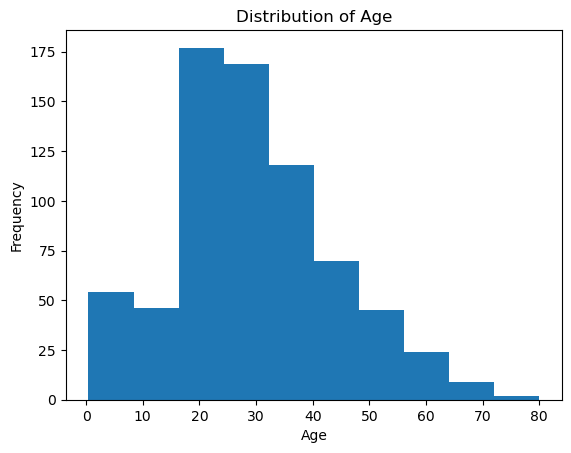

In [35]:
# Creating a basic histogram using Mathplotlib
plt.hist(df['Age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

Other modules like Seaborn are built on top of Matplotlib and can do a bit more. It can create more attractive visualizations and can sometimes make it easier to do more complex plotting.

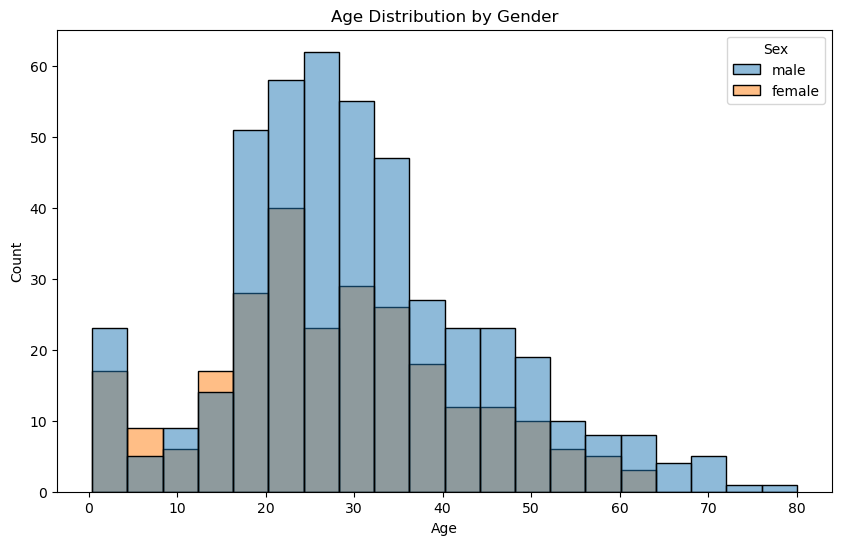

In [37]:
# A Seaborn histogram
plt.figure(figsize=(10, 6))
sb.histplot(data=df, x='Age', hue='Sex')
plt.title('Age Distribution by Gender')
plt.show()

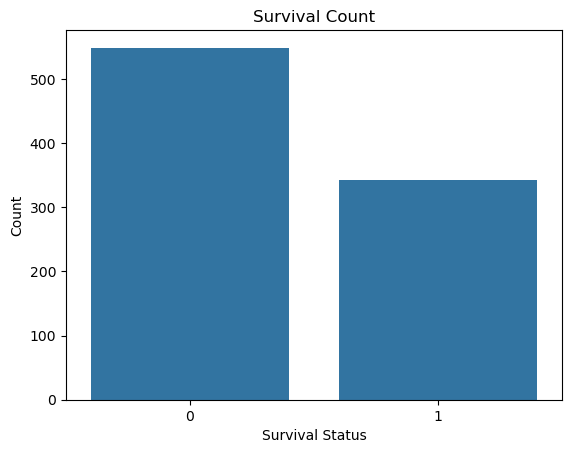

In [39]:
# A Seaborn Bar plot
sb.countplot(x='Survived', data=df)
plt.xlabel('Survival Status')
plt.ylabel('Count')
plt.title('Survival Count')
plt.show()

In [ ]:
# A Seaborn categorical bar plot
sb.catplot(x ="Sex", hue ="Survived", kind ="count", data = df) 

### Model Exploration

Suppose we wanted to see if we could predict who would survive on the Titanic by using certain columns/features.  Let's clean up the data and run it through a decision tree model.

Recall that age has quite a few missing values. One common data wrangling task is addressing missing values. We'll talk more in detail about how to do this, but for now we are going to replace missing ages with the mean age. We'll also manipulate other columns to address other missing values (more on this in a future class). 

In [ ]:
# Filling missing values in age with a specific value
df['Age'] = df['Age'].fillna(ave_age)

# Filling missing values in embarked with a specific value
df['Embarked'] = df['Embarked'].fillna('S')

# Cabin feature/column is missing a lot of data, let's just drop it
df = df.drop(['Cabin'], axis=1)

In [ ]:
# Verifying that the above worked and that we no longer have missing data
df.isnull().sum()
df.info()

We also need to represent certain features a bit differently in order to use them with the DecisionTreeClassifier below.

In [ ]:
# encoding categorical data
df = pd.get_dummies(df, columns=['Sex'], prefix='Sex')
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')

Now we'll create a simple decision tree model and view it visually.

In [ ]:
decision_tree = DecisionTreeClassifier(max_depth = 3)
y_train = df['Survived'].values
x_train = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Fare'], axis=1).values

decision_tree.fit(x_train, y_train)

class_names = ['Died', 'Survived']

fig = plt.figure(figsize=(25,20))
tree.plot_tree(decision_tree, feature_names = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Fare'], axis=1).columns.values, class_names=class_names )

### Review Questions

1. You messed up your data and need to restart your Notebook. How do you do this?
2. What does [*] mean in a notebook when it is to the left of a cell?
3. What is the extension of Juypter notebooks?
4. What happens when you type in a code cell: print?
5. How do I make text bold in a notebook? Italic?

***That's it for today's basic overview.***